# Groupwise operations: split/apply/combine

Peter Ralph  
2026-01-21

# Goals

You have used
[“split/apply/combine”](https://www.jstatsoft.org/article/view/v040i01/468)
operations, e.g.,
[pd.DataFrame.aggregate](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html).
Our goal here is to think about best practices/workflows and get some
practice with different applications, on a concrete dataset.

## The data: Weather Underground

We looked at the “personal weather station” datat from Weather
Underground in a previous class: [Weather
Data](../slides/weather_intro.html).

Here’s the data:

-   a table of local stations: [stations.csv](data/stations.csv)
-   a zip file of data: [weather_data](data/weather_data.zip) (unzip to
    `data/`)

## Parsing code

From your homework, here’s code to read in the files:

In [34]:
wfiles = glob.glob("data/weather_data" + "/" + "*.csv")
wfiles[0], wfiles[0].split("/")[-1].split("_")[0]

('data/weather_data/KOREUGEN74_2015.csv', 'KOREUGEN74')

In [2]:
import glob
import pandas as pd
import numpy as np

def make_date(x):
    """
    Makes a datetime object out of the Date and Time columns
    """
    return pd.to_datetime(x['Date'] + " " + x['Time'], format="%Y/%m/%d %I:%M %p")

def compute_precip(x):
    """
    Returns for each entry the amount of precipitation that has accumulated
    in the previous five minutes, inserting NA for any entry for which either:
        - the difference in accumulated precipitation is negative, or
        - the previous entry was not five minutes ago.
    """
    dt = x["Date"].diff().dt.seconds
    dp = np.maximum(0, x['Precip_Accum_mm'].diff()).mask(dt != 300, pd.NA)
    return dp

def read_weather_files(ddir):
    """
    Reads in all CSV files in the directory `ddir`, and returns a concatenated
    data frame. For each file, assumes that file names are of the form
    "something_CODE.csv"; and inserts "CODE into the "code" column of the result
    for that file.
    """
    wfiles = glob.glob(ddir + "/" + "*.csv")
    assert len(wfiles) > 0, "No files found."
    xl = []
    for f in wfiles:
        x = pd.read_csv(f).convert_dtypes()
        x['Date'] = make_date(x)
        x['code'] = f.split("/")[-1].split("_")[0]
        x['Precip_Amount_mm'] = compute_precip(x)
        xl.append(x)
    
    return pd.concat(xl)

## 

Let’s have a look!

In [3]:
import plotnine as p9

stations = pd.read_csv("data/stations.csv")
stations

,name,code,lat,lon,elev
0,BETHEL,KOREUGEN31,44.080,123.200,380
1,Torrington Station,KOREUGEN67,44.120,123.150,377
2,South Eugene,KOREUGEN74,44.030,123.110,440
3,South University,KOREUGEN127,44.037,123.074,470
4,Old Baldy,KOREUGEN225,44.000,123.070,800
5,Lafferty Park,KOREUGEN226,44.020,123.100,640
6,Crescent Ave,KOREUGEN249,44.090,123.080,410
7,Alvadore,KOREUGEN260,44.100,123.270,400
8,Lema,KOREUGEN295,44.080,123.130,410
9,College Hill,KOREUGEN303,44.030,123.100,587


##

In [5]:
weather = read_weather_files("data/weather_data")
weather

,Date,Time,Temperature_C,Dew_Point_C,Humidity_%,Wind,Speed_kmh,Gust_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,UV,Solar_w/m2,code,Precip_Amount_mm
0,2015-12-28 17:39:00,05:39 PM,5.61,5.28,98,SSW,0.0,0.0,1013.88,0.0,0.0,0,0.0,KOREUGEN74,<NA>
1,2015-12-28 17:42:00,05:42 PM,5.61,5.5,99,WSW,0.0,0.0,1013.88,0.0,0.0,0,0.0,KOREUGEN74,<NA>
2,2015-12-28 17:47:00,05:47 PM,5.72,5.61,99,West,3.22,11.91,1013.88,0.0,0.0,0,0.0,KOREUGEN74,0.0
3,2015-12-28 17:52:00,05:52 PM,5.72,5.61,99,West,0.0,0.0,1013.88,0.0,0.0,0,0.0,KOREUGEN74,0.0
4,2015-12-28 17:57:00,05:57 PM,5.72,5.61,99,SSE,0.0,0.0,1013.55,0.0,0.0,0,0.0,KOREUGEN74,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98536,2025-12-31 23:39:00,11:39 PM,2.0,1.78,99,NNW,0.0,0.0,1013.55,0.0,0.0,0,0.0,KOREUGEN127,0.0
98537,2025-12-31 23:44:00,11:44 PM,2.0,1.78,99,NNW,0.32,0.48,1013.21,0.0,0.0,0,0.0,KOREUGEN127,0.0
98538,2025-12-31 23:49:00,11:49 PM,2.0,1.78,99,NNW,0.0,0.0,1013.21,0.0,0.0,0,0.0,KOREUGEN127,0.0
98539,2025-12-31 23:54:00,11:54 PM,2.11,1.89,99,NNW,0.0,0.0,1013.21,0.0,0.0,0,0.0,KOREUGEN127,0.0


## Beware

In [6]:
pd.crosstab( weather['code'], weather['Date'].dt.year)

Date,2015,2024,2025
code,,,
KOREUGEN127,0,0,98541
KOREUGEN249,0,0,97346
KOREUGEN267,0,0,77024
KOREUGEN295,0,0,97577
KOREUGEN303,0,0,97480
KOREUGEN307,0,0,98181
KOREUGEN31,102093,102832,0
KOREUGEN319,0,0,75207
KOREUGEN321,0,0,92791


## Goals:

What we’d like to do is **understand how well measurements in one part
of Eugene/Springfield predicts measurements in another part**. In
particular, how well does rainfall at one point – the [National Weather
Service
station](https://forecast.weather.gov/MapClick.php?lat=44.0520691&lon=-123.08675360000001)
– predict load for the municipal stormwater system?

*So:* let’s understand the data, with this goal in mind.

# Summarizing

Sometimes we want to compute *one* (or, a few) summary stats per group.

## Mean temperature, by day of the year

In [19]:
# function that returns a function
def f(x):
    def g(y):
        return x + y
    return g

F = f(3)
F(2)

5

In [16]:
def get_day(df):
    day = df["Date"].dt.dayofyear
    return day

weather.assign(day = get_day)

,Date,Time,Temperature_C,Dew_Point_C,Humidity_%,Wind,Speed_kmh,Gust_kmh,Pressure_hPa,Precip_Rate_mm,Precip_Accum_mm,UV,Solar_w/m2,code,Precip_Amount_mm,day
0,2015-12-28 17:39:00,05:39 PM,5.61,5.28,98,SSW,0.0,0.0,1013.88,0.0,0.0,0,0.0,KOREUGEN74,<NA>,362
1,2015-12-28 17:42:00,05:42 PM,5.61,5.5,99,WSW,0.0,0.0,1013.88,0.0,0.0,0,0.0,KOREUGEN74,<NA>,362
2,2015-12-28 17:47:00,05:47 PM,5.72,5.61,99,West,3.22,11.91,1013.88,0.0,0.0,0,0.0,KOREUGEN74,0.0,362
3,2015-12-28 17:52:00,05:52 PM,5.72,5.61,99,West,0.0,0.0,1013.88,0.0,0.0,0,0.0,KOREUGEN74,0.0,362
4,2015-12-28 17:57:00,05:57 PM,5.72,5.61,99,SSE,0.0,0.0,1013.55,0.0,0.0,0,0.0,KOREUGEN74,0.0,362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98536,2025-12-31 23:39:00,11:39 PM,2.0,1.78,99,NNW,0.0,0.0,1013.55,0.0,0.0,0,0.0,KOREUGEN127,0.0,365
98537,2025-12-31 23:44:00,11:44 PM,2.0,1.78,99,NNW,0.32,0.48,1013.21,0.0,0.0,0,0.0,KOREUGEN127,0.0,365
98538,2025-12-31 23:49:00,11:49 PM,2.0,1.78,99,NNW,0.0,0.0,1013.21,0.0,0.0,0,0.0,KOREUGEN127,0.0,365
98539,2025-12-31 23:54:00,11:54 PM,2.11,1.89,99,NNW,0.0,0.0,1013.21,0.0,0.0,0,0.0,KOREUGEN127,0.0,365


In [22]:
day_temp = (
    weather.assign(day = lambda df: df['Date'].dt.dayofyear)
    .groupby("day")
    .aggregate(
        Temperature_C = ("Temperature_C", "mean"),
    ).reset_index()
)
day_temp

,day,Temperature_C
0,1,5.384088
1,2,7.075204
2,3,7.672223
3,4,7.919059
4,5,8.865104
...,...,...
361,362,3.729265
362,363,3.596271
363,364,2.461338
364,365,1.456371


##

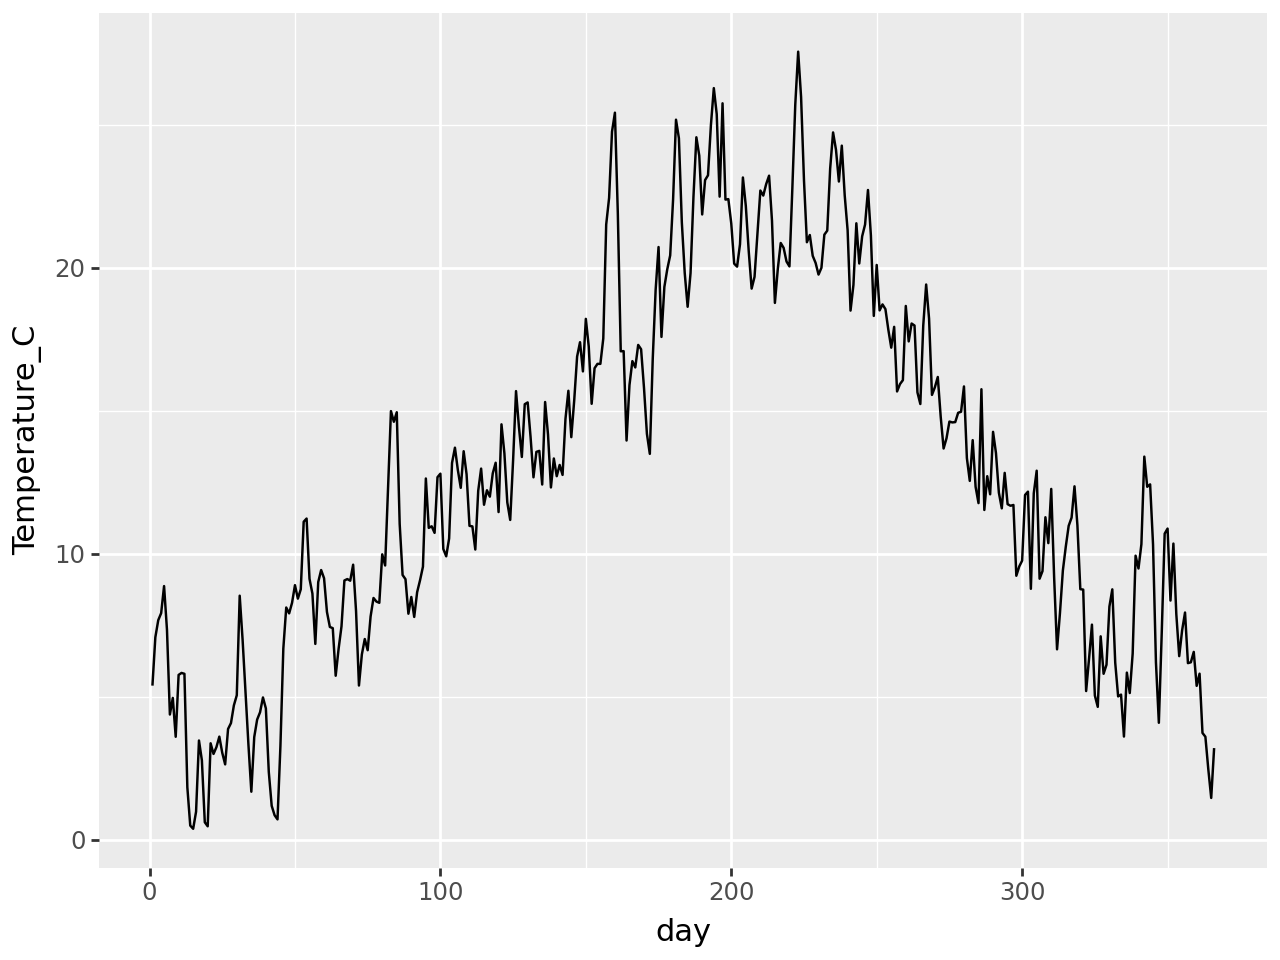

In [23]:
(
    p9.ggplot(day_temp, p9.aes(x="day", y="Temperature_C")) + p9.geom_line()
)

## Mean total daily precip, by day of the year

*(“Mean” across what?)*

In [26]:
daily_precip = (
    weather.assign(day = lambda df: df['Date'].dt.dayofyear)
    .groupby(["day", "code"])
    .aggregate(
        Precip_Amount_mm = ("Precip_Amount_mm", "sum"),
    ).reset_index()
    .groupby("day")
    .aggregate(
        Precip_Amount_mm = ("Precip_Amount_mm", "mean"),
    ).reset_index()
)
daily_precip

,day,Precip_Amount_mm
0,1,4.7825
1,2,20.169167
2,3,8.295833
3,4,8.000833
4,5,10.140909
...,...,...
361,362,4.973333
362,363,5.334167
363,364,3.848462
364,365,0.331538


##

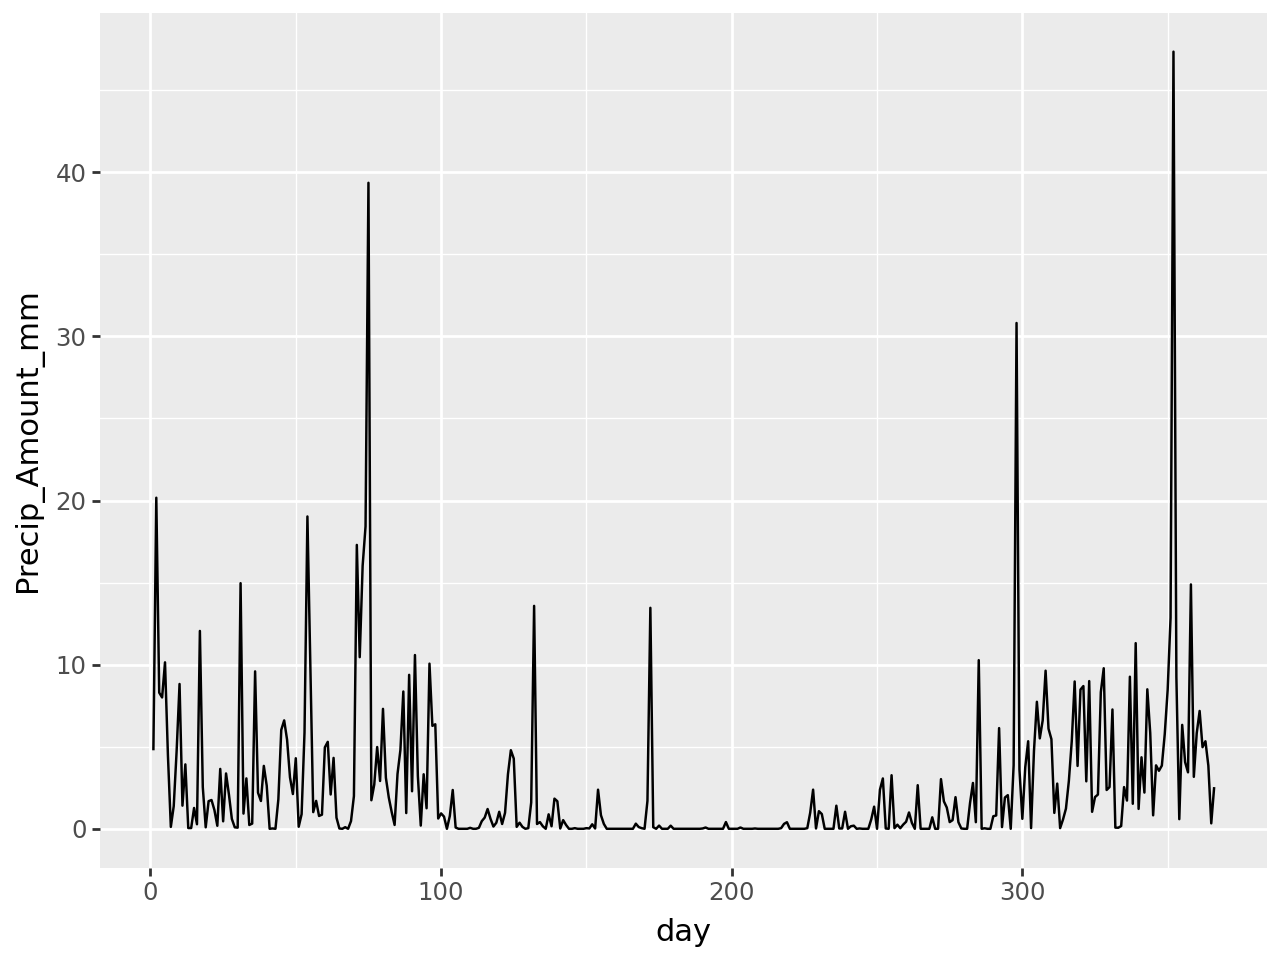

In [27]:
p9.ggplot(daily_precip, p9.aes(x='day', y='Precip_Amount_mm')) + p9.geom_line()

## Brainstorming

What are some other summaries?

- sum of (average across days of wind gust speed) across locations
- average (max UV per day)
- average for each day and location of (temperature and also humidity)

# Transforming

Other times, we want to transform each value to a new value, but in a
way that depends on the group.

## Station temperature relative to daily average

In [36]:
weather['seasonal_temp'] = (
    weather
    .assign(day = lambda df: df['Date'].dt.dayofyear)
    .loc[:,['day', 'Temperature_C']]
    .groupby("day")
    .transform('mean')
)

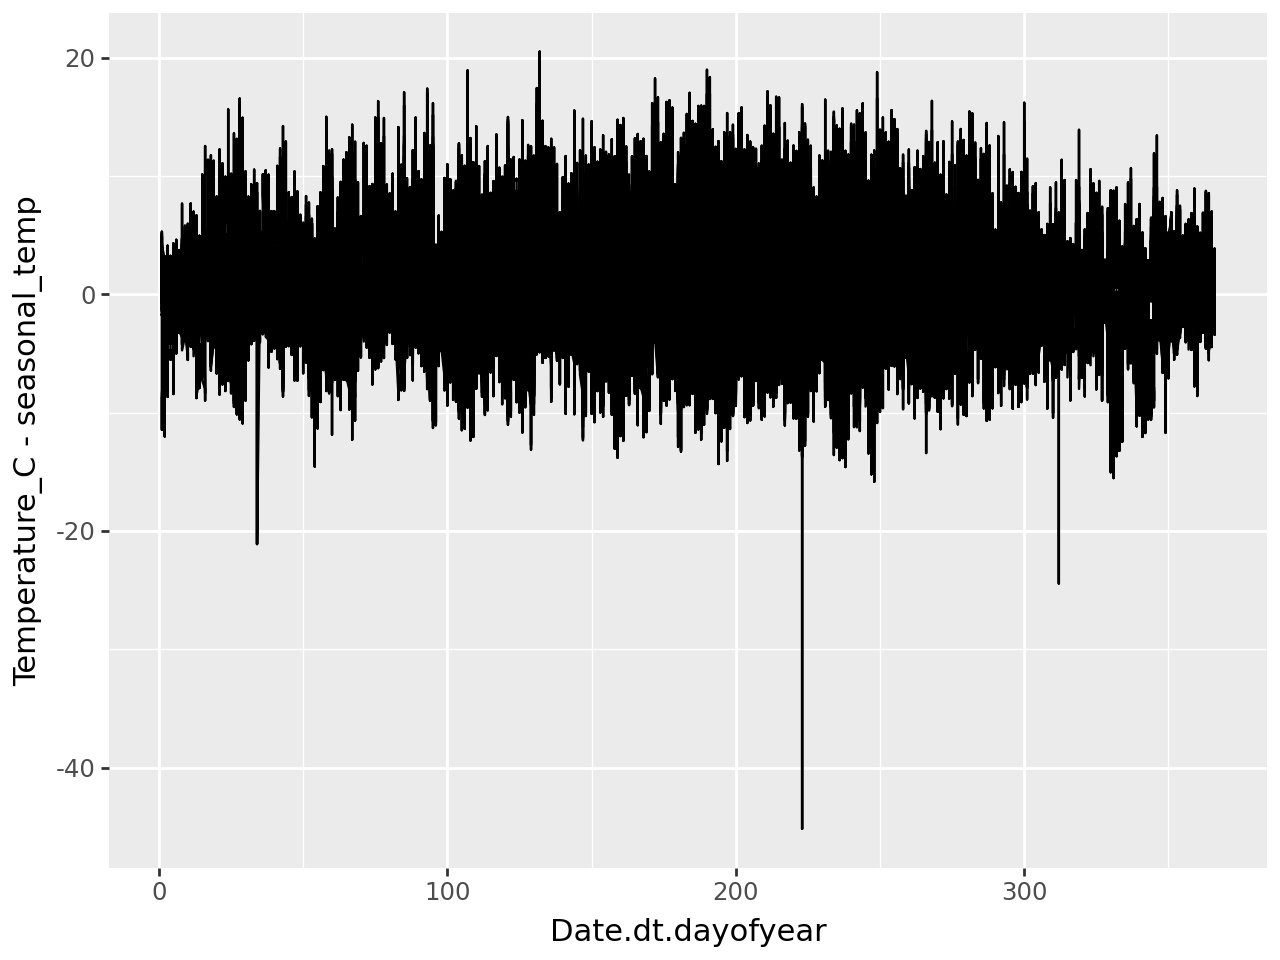

In [43]:
(
    weather
    >>
    p9.ggplot(p9.aes(x='Date.dt.dayofyear', y='Temperature_C - seasonal_temp', group='code'))
    + p9.geom_line()
)

## Station temperature relative to regional average

In [44]:
hourly_weather = (
    weather.loc[:,['code', 'Date', 'Temperature_C', 'Precip_Amount_mm']]
    .assign(Date = lambda df: df['Date'].dt.round('h'))
    .groupby(["code", 'Date'])
    .mean()
    .reset_index()
)
# difference between the temperature
# and the average temperature across all locations
# at that time
hourly_weather['temp_relative'] = (
    hourly_weather.loc[:,['Date','Temperature_C']]
    .groupby("Date")
    .transform(
        lambda x: x - x.mean()
    )
)

In [45]:
hourly_weather

,code,Date,Temperature_C,Precip_Amount_mm,temp_relative
0,KOREUGEN127,2025-01-01 00:00:00,4.798333,0.05,-0.141131
1,KOREUGEN127,2025-01-01 01:00:00,4.665,0.021667,-0.23094
2,KOREUGEN127,2025-01-01 02:00:00,4.699167,0.020833,-0.25664
3,KOREUGEN127,2025-01-01 03:00:00,4.89,0.0,-0.200818
4,KOREUGEN127,2025-01-01 04:00:00,4.944167,0.0,-0.18775
...,...,...,...,...,...
114259,KOREUGEN74,2025-12-31 20:00:00,-0.204167,0.0,-0.825076
114260,KOREUGEN74,2025-12-31 21:00:00,0.1725,0.0,-0.837287
114261,KOREUGEN74,2025-12-31 22:00:00,0.860833,0.0,-0.595637
114262,KOREUGEN74,2025-12-31 23:00:00,1.5175,0.0,-0.377831


## Brainstorming

What’s another transformation?

# Multi-level splits

When things get complicated, two important skills are:

1.  write out what you want to do, carefully, and
2.  double-check that you’ve done the right thing.

## 

*Question:* What’s the difference between these? What does each tell
you, in real-world terms?

1.  mean of (standard deviation of daily rainfall over January) across
    locations

2.  standard deviation of (mean of daily rainfall over January) across
    locations